# STEP ONE: Handling the Dataset


Dependencies and Libraries

In [1]:
# Install core libraries: transformers UPGRADED (model and tokenizer), datasets (data), scikit-learn (baseline stuff and metrics)
#!pip install -U transformers
#!pip install datasets scikit-learn

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [2]:
# Discrepency between evaluation_strategy and save_strategy because outdated HuggingFace Transformers, so upgraded transformers with -U above
# 5.5.4, which is greater than 4.0!
import transformers
print(transformers.__version__)

d:\CodingHomework\CS5480-FInalProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5.6.2


Dataset Loading from Drive

In [3]:
# Mount from Drive
#from google.colab import drive
#drive.mount('/content/drive')

# Set a base path connection, so all this doesn't need to be typed EACH time
BASE_PATH = ""
RESULTS_PATH = BASE_PATH + "results/"
MODEL_PATH = BASE_PATH + "models/"

os.makedirs(RESULTS_PATH, exist_ok = True)
os.makedirs(MODEL_PATH, exist_ok = True)

In [4]:
# Separate columns based on features
COLUMNS = ["id", "label", "statement", "subject", "speaker", "job", "state", "party", "barely_true", "false", "half_true", "mostly_true", "pants_fire", "context"]

# .tsv files read, NOT .csv, so sep = "\t"
def load_liar(path):
    return pd.read_csv(path, sep = "\t", header = None, names = COLUMNS)

# Upload .tsv files for preprocessing
train_df = load_liar(BASE_PATH + "train.tsv")
val_df   = load_liar(BASE_PATH + "valid.tsv")
test_df  = load_liar(BASE_PATH + "test.tsv")

Preprocessing

In [5]:
# Six features for truthfulness (0-5)
label_map = {"pants-fire": 0, "false": 1, "barely-true": 2, "half-true": 3, "mostly-true": 4, "true": 5}

# Preprocess each file: drop missing statements, 1-hot-encoding for "false" categorical variables, strip whitespace (but keep text the same)
def preprocess(df):
  df = df.copy()
  df = df.dropna(subset=["statement"])
  df["statement"] = df["statement"].astype(str)
  df["statement"] = df["statement"].str.strip()
  df["label"] = df["label"].map(label_map)
  return df[["statement", "label"]]

train_df = preprocess(train_df)
val_df   = preprocess(val_df)
test_df  = preprocess(test_df)

# Only Text (input) and Label (output, which is specified above) kept for current relevancy
train_df = train_df.rename(columns = {"statement": "text"})
val_df   = val_df.rename(columns = {"statement": "text"})
test_df  = test_df.rename(columns = {"statement": "text"})

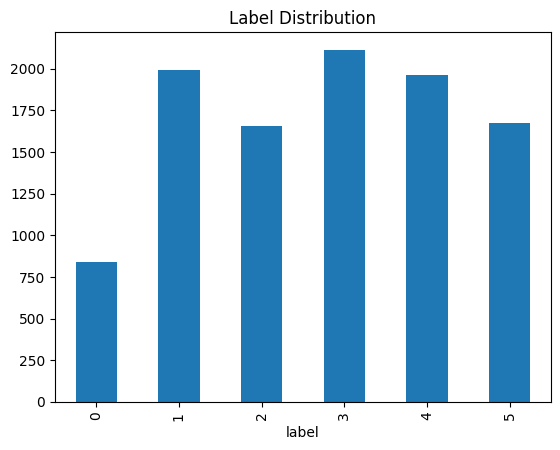

In [6]:
# LIAR imbalances mean some classes are rarer, so value_counts for how many examples per layer

train_df["label"].value_counts().sort_index().plot(kind = "bar")
plt.title("Label Distribution")
plt.savefig(RESULTS_PATH + "label_dist.png")
plt.show()

# Results show WAY less for pants-fire

# STEP TWO: The Baseline Model

In [7]:
# TF-IDF for word2vec conversion: bases on importance of word frequency
from sklearn.feature_extraction.text import TfidfVectorizer

# Logistic Regression as baseline for above features
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(max_features = 5000)

X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])

y_train = train_df["label"]
y_val = val_df["label"]

clf = LogisticRegression(max_iter = 1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)

baseline_acc = accuracy_score(y_val, y_pred)
baseline_f1 = f1_score(y_val, y_pred, average = 'macro')

print("Baseline Accuracy:", baseline_acc)
print("Baseline F1 Score:", baseline_f1)

# RESULTS
# Baseline Accuracy: 0.23909657320872274
# Baseline F1 Score: 0.22423559784045832

Baseline Accuracy: 0.23909657320872274
Baseline F1 Score: 0.22423559784045832


Confusion Matrix

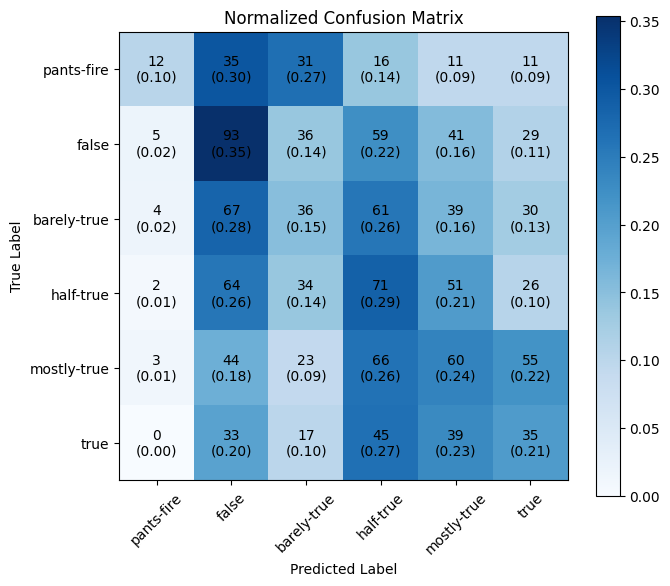

In [8]:
# Analysis of true positives, false negatives, true negatives, and false positives

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

labels = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]

# Normalize to understand ACTUAL proportions (class imbalances)
cm_norm = cm.astype('float') / cm.sum(axis = 1, keepdims = True)

# Plot heatmap/confusion matrix w/ blue gradient (best color, duh)
plt.figure(figsize = (7, 6))
plt.imshow(cm_norm, cmap = "Blues")
plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(6), labels, rotation = 45)
plt.yticks(np.arange(6), labels)

# Print percentages for each box in matrix (both raw counts AND percentages)
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.2f})", ha = "center", va = "center", color = "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(RESULTS_PATH + "baseline_cm.png")
plt.show()

# RESULTS
# Accuracies Per Class: Pants-Fire (10%), False (35%), Barely-True (15%), Half-True (29%), Mostly-True (24%), True (21%)
# Highest Prediction Attributed Per Class: Pants-Fire (30% for False), False (35% for False) Barely-True (28% for False), Half-True (29% for Half-True), Mostly-True (26% for Half-True), True (27% for Half-True)
# Barely predicts pants-fire (rare class) and vice versa for frequent classes (false and half-true), predictions mainly false, half-true, or mostly-true
# Class imbalance significantly affects performance -- which is why class-weighted loss can prove very useful.

In [9]:
# Save results in a .txt file for later comparison
with open(RESULTS_PATH + "baseline.txt", "w") as f:
  f.write(f"Accuracy: {baseline_acc}\nF1 Score: {baseline_f1}")

# STEP THREE: RoBERTa Model


Tokenization Process

In [10]:
# Pull up dataset for training model
from datasets import Dataset

# Convert pandas DataFrame to HuggingFace dataset format for transformers' Trainer format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

In [11]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Convert text to inputs for RoBERTa model (words --> tokens, tokens --> IDs, and padding/truncation)
def tokenize(batch):
  return tokenizer(batch["text"], padding = "max_length", truncation = True, max_length = 128)

# Train based on above
train_dataset = train_dataset.map(tokenize, batched = True)
val_dataset = val_dataset.map(tokenize, batched = True)

train_dataset.set_format(type = "torch", columns = ["input_ids", "attention_mask", "label"])
val_dataset.set_format(type = "torch", columns = ["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 1284/1284 [00:00<00:00, 25687.25 examples/s]


In [12]:
# Fine-tuning the pre-trained model
from transformers import AutoModelForSequenceClassification

# Load pre-trained RoBERTa with classification head and the 6 output labels
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels = 6)

# RESULTS
# RobertaForSequenceClassification LOAD REPORT from: roberta-base
# Key                             | Status     |
# --------------------------------+------------+-
# lm_head.layer_norm.bias         | UNEXPECTED |
# lm_head.dense.bias              | UNEXPECTED |
# lm_head.layer_norm.weight       | UNEXPECTED |
# lm_head.bias                    | UNEXPECTED |
# roberta.embeddings.position_ids | UNEXPECTED |
# lm_head.dense.weight            | UNEXPECTED |
# classifier.dense.weight         | MISSING    |
# classifier.out_proj.bias        | MISSING    |
# classifier.out_proj.weight      | MISSING    |
# classifier.dense.bias           | MISSING    |

# Notes:
# - UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
# - MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5302.98it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
# Function for the metrics
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis = 1)

  # Macro-F1 better for class imbalance than accuracy
  acc = accuracy_score(labels, preds)
  f1 = f1_score(labels, preds, average = 'macro')

  return {"accuracy": acc, "macro_f1": f1}

Training

In [14]:
# Error with parameter names, so print names to check
import transformers
from transformers import TrainingArguments

print(transformers.__version__)
print(TrainingArguments.__init__.__code__.co_varnames)
print(torch.version.cuda)


5.6.2
('self', 'output_dir', 'per_device_train_batch_size', 'num_train_epochs', 'max_steps', 'learning_rate', 'lr_scheduler_type', 'lr_scheduler_kwargs', 'warmup_steps', 'optim', 'optim_args', 'weight_decay', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'optim_target_modules', 'gradient_accumulation_steps', 'average_tokens_across_devices', 'max_grad_norm', 'label_smoothing_factor', 'bf16', 'fp16', 'bf16_full_eval', 'fp16_full_eval', 'tf32', 'gradient_checkpointing', 'gradient_checkpointing_kwargs', 'torch_compile', 'torch_compile_backend', 'torch_compile_mode', 'use_liger_kernel', 'liger_kernel_config', 'use_cache', 'neftune_noise_alpha', 'torch_empty_cache_steps', 'auto_find_batch_size', 'logging_strategy', 'logging_steps', 'logging_first_step', 'log_on_each_node', 'logging_nan_inf_filter', 'include_num_input_tokens_seen', 'log_level', 'log_level_replica', 'disable_tqdm', 'report_to', 'run_name', 'project', 'trackio_space_id', 'trackio_bucket_id', 'trackio_static_space_id', 'eval_strat

In [ ]:
from transformers import Trainer, TrainingArguments

# Forward pass for predictions, compute loss, backprop, and update model's weights -- REPEAT over epochs
training_args = TrainingArguments(output_dir = MODEL_PATH, num_train_epochs = 2, per_device_train_batch_size = 16, per_device_eval_batch_size = 16, eval_strategy = "epoch", save_strategy = "epoch", logging_dir = RESULTS_PATH)

# Subset with select(range(5000)) for faster iteration but progress depictions
trainer = Trainer(model = model, args = training_args, train_dataset = train_dataset.select(range(5000)), eval_dataset = val_dataset.select(range(1000)), compute_metrics = compute_metrics)

trainer.train()

# RESULTS
# Epoch	Training Loss	Validation Loss	Accuracy	Macro F1
# 1	    No log	        1.765655	    0.210000	0.086462
# 2	    1.739255	    1.706569	    0.263000	0.144355
# TrainOutput(global_step=626, training_loss=1.728209717966878, metrics={'train_runtime': 248.9603, 'train_samples_per_second': 40.167, 'train_steps_per_second': 2.514, 'total_flos': 657801262080000.0, 'train_loss': 1.728209717966878, 'epoch': 2.0})

# Validation loss decreases from 1.765655 to 1.706569 (model seems to learn generalized patterns better after training).
# Accuracy from 21% to 26.3%, showing improvement over epochs, but weak performance overall.
# Macro F1 (model performance across all classes equally) increases from 0.086462 to 0.144355, still showing strong imbalance among predictions.
# Despite accuracy improvement, model is still failing to learn balanced representations across the 6 LIAR features (biased towards frequent labels and struggles with fine-grained distinctions).
# Roberta F1 lower than baseline, probably due to mild overfitting of dominant classes; thus, class weights should be addressed for these metrics, specifically.

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.774393,0.196000,0.054627
2,1.765531,1.768512,0.199000,0.055324


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.40it/s]


TrainOutput(global_step=626, training_loss=1.7640294815404727, metrics={'train_runtime': 125.1935, 'train_samples_per_second': 79.876, 'train_steps_per_second': 5.0, 'total_flos': 657801262080000.0, 'train_loss': 1.7640294815404727, 'epoch': 2.0})

# STEP FOUR: New RoBERTa Model (Classification Weights)

In [16]:
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoModelForSequenceClassification
base_model_name = "roberta-base"

model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels = 6, ignore_mismatched_sizes=True)

# Find the unique classes in the training data
unique_classes = np.unique(y_train)

# Calculate the weights
raw_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)

# Apply the Square Root to dampen the extreme penalties
smoothed_weights = np.sqrt(raw_weights)

print(f"Raw weights: {raw_weights}")
print(f"Smoothed weights: {smoothed_weights}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6419.64it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Raw weights: [2.03416766 0.85547201 1.031842   0.8073163  0.86986069 1.01829753]
Smoothed weights: [1.4262425  0.9249173  1.01579624 0.89850782 0.93266322 1.0091073 ]


In [17]:
from transformers import Trainer

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Convert your calculated weights to a tensor and move to the appropriate device
        weight_tensor = torch.tensor(raw_weights, dtype=torch.float).to(model.device)

        # Apply the weights to the CrossEntropyLoss
        loss_fct = torch.nn.CrossEntropyLoss(weight=weight_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [18]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir = MODEL_PATH, 
    logging_dir = RESULTS_PATH,
    num_train_epochs = 4, 
    learning_rate = 2e-5,
    warmup_ratio = 0.1,
    per_device_train_batch_size = 32, 
    per_device_eval_batch_size = 32, 
    optim = "adamw_torch", 
    eval_strategy = "epoch", 
    save_strategy = "epoch",
)
trainer = CustomTrainer(model = model, args = training_args, train_dataset = train_dataset, eval_dataset = val_dataset, compute_metrics = compute_metrics)

trainer.train()

#Results:
# Epoch	Training Loss   Validation Loss	    Accuracy	    Macro F1
# 1	    No log	        1.705128	        0.221963	    0.197250
# 2	    1.740097	    1.660059	        0.269470	    0.259901
# 3	    1.740097	    1.717745	        0.267913	    0.267355
# 4	    1.568681	    1.745737	        0.267913	    0.271299
#TrainOutput(global_step=1280, training_loss=1.602678155899048, metrics={'train_runtime': 375.0141, 'train_samples_per_second': 109.223, 'train_steps_per_second': 3.413, 'total_flos': 2694353969479680.0, 'train_loss': 1.602678155899048, 'epoch': 4.0})

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.718701,0.222741,0.175489
2,1.749087,1.667522,0.258567,0.242878
3,1.749087,1.714608,0.265576,0.263471
4,1.590484,1.735042,0.269470,0.271002


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]


TrainOutput(global_step=1280, training_loss=1.6224767446517945, metrics={'train_runtime': 395.0173, 'train_samples_per_second': 103.692, 'train_steps_per_second': 3.24, 'total_flos': 2694353969479680.0, 'train_loss': 1.6224767446517945, 'epoch': 4.0})

Classification Report:
              precision    recall  f1-score   support

  pants-fire       0.29      0.38      0.33       116
       false       0.27      0.16      0.20       263
 barely-true       0.25      0.24      0.25       237
   half-true       0.27      0.19      0.23       248
 mostly-true       0.31      0.33      0.32       251
        true       0.24      0.41      0.30       169

    accuracy                           0.27      1284
   macro avg       0.27      0.29      0.27      1284
weighted avg       0.27      0.27      0.26      1284



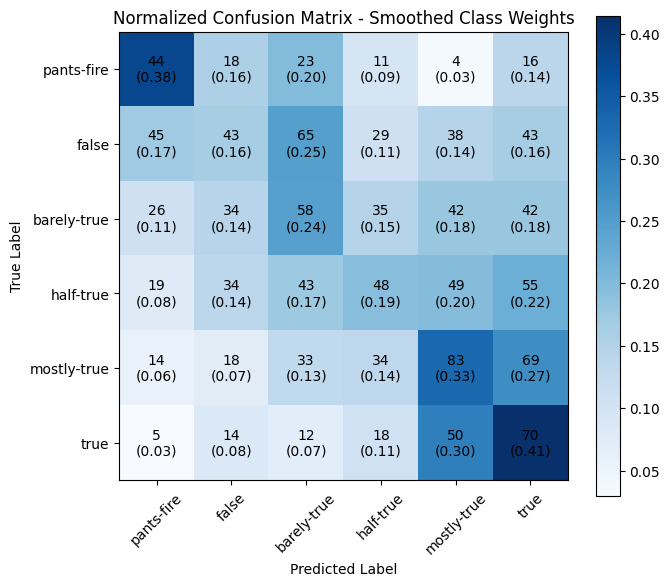

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("Classification Report:")
print(classification_report(true_labels, preds, target_names=labels))

predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, preds)

labels = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
plt.imshow(cm_norm, cmap="Blues")
plt.title("Normalized Confusion Matrix - Smoothed Class Weights")
plt.colorbar()

plt.xticks(np.arange(6), labels, rotation=45)
plt.yticks(np.arange(6), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.2f})", ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(RESULTS_PATH + "weighted_cm.png")
plt.show()

# Classification Report:
#              precision    recall  f1-score   support
#
#  pants-fire       0.29      0.38      0.33       116
#       false       0.27      0.16      0.20       263
# barely-true       0.25      0.24      0.25       237
#   half-true       0.27      0.19      0.23       248
# mostly-true       0.31      0.33      0.32       251
#        true       0.24      0.41      0.30       169
#
#    accuracy                           0.27      1284
#   macro avg       0.27      0.29      0.27      1284
# weighted avg      0.27      0.27      0.26      1284

Saved results/model_comparison.png


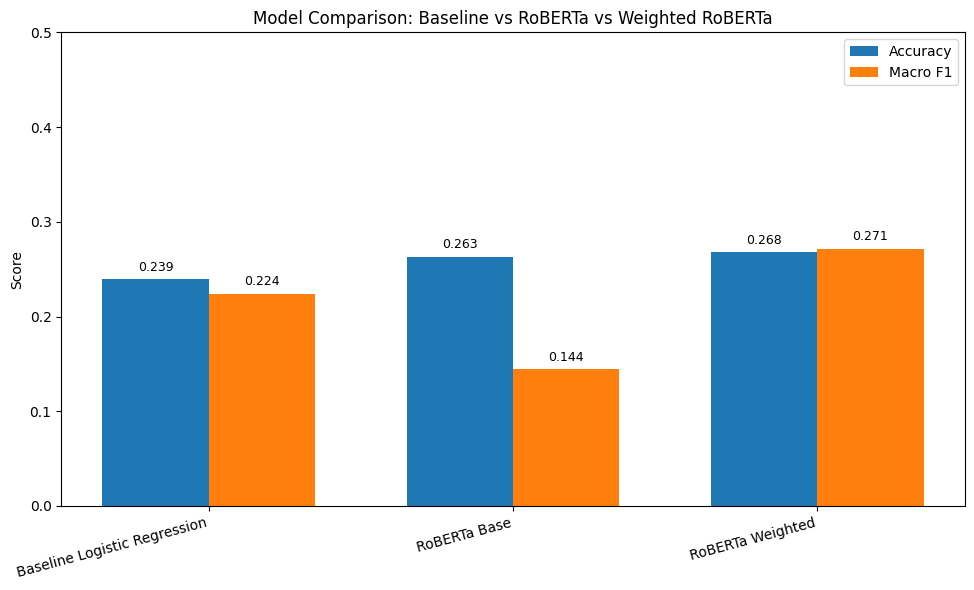

In [23]:
labels = ["Baseline Logistic Regression", "RoBERTa Base", "RoBERTa Weighted"]
accuracies = [0.23909657320872274, 0.263000, 0.267913]
f1_scores = [0.22423559784045832, 0.144355, 0.271299]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, accuracies, width, label="Accuracy")
bars2 = ax.bar(x + width / 2, f1_scores, width, label="Macro F1")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Baseline vs RoBERTa vs Weighted RoBERTa")
ax.set_ylim(0, 0.5)
ax.legend()

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.annotate(f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig('d:/CodingHomework/CS5480-FInalProject/results/model_comparison.png')
print('Saved results/model_comparison.png')